# Gráficos de cotações de uma ação da B3

Este notebook busca séries temporais de cotações históricas de uma ação da B3 na API Yahoo!Finance e faz gráficos diversos.

Data da última atualização: 18/08/2025

### Preliminares

In [6]:
# Instalação da API Yahoo!Finance, caso ainda não instalada
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Carregamento das bibliotecas NumPy e Pandas
import numpy  as np
import pandas as pd

# API Yahoo!Finance - base de dados do mercado financeiro
!pip install yfinance
import yfinance as yf

# Carregamento do recurso plotly.graph_objects da biblioteca Plotly
!pip install plotly
import plotly.graph_objects as go
import matplotlib.pyplot as plt

### Seleção da ação e do período

#### Código da ação

In [8]:
# Definição do código de negociação da ação na B3
AcaoB3 = 'VALE3'

In [9]:
# Ajuste do código da ação na API Yahoo!Finance
CodigoYF = AcaoB3 + '.SA'

#### Seleção das datas inicial e final

A API Yahoo!Finance possui dados desde 1970 (no caso de ativos da B3, há dados desde 2000), até o último dia de negociação fechado.

Aqui será selecionado o maior período com dados disponíveis para o ativo escolhido.

In [10]:
# Ajuste da data inicial
DataInicial = '1970-01-01'

# Ajuste da data final para o dia de hoje
DataFinal = str(pd.to_datetime('today').date())

### Carregamento dos dados históricos

In [11]:
# Leitura de dados históricos da API Yahoo!Finance
CotacoesDF = yf.download(CodigoYF, start = DataInicial, end = DataFinal)

[*********************100%***********************]  1 of 1 completed


In [12]:
# Visualização do DataFrame
CotacoesDF

Price,Close,High,Low,Open,Volume
Ticker,VALE3.SA,VALE3.SA,VALE3.SA,VALE3.SA,VALE3.SA
Date,,,,,
2000-01-03,1.287471,1.303105,1.287471,1.287471,585600
2000-01-04,1.256817,1.277968,1.256817,1.275209,782400
2000-01-05,1.256817,1.256817,1.241490,1.241490,1876800
2000-01-06,1.256817,1.287471,1.256817,1.256817,792000
2000-01-07,1.302798,1.309236,1.272144,1.272144,5347200
...,...,...,...,...,...
2026-07-29,75.050003,76.199997,74.610001,76.010002,12265200
2026-07-30,76.089996,76.559998,74.610001,75.980003,16732800


### Mudança de granularidade

In [13]:
# Defina a periodicidade desejada:
# - anual
# - trimestral
# - mensal
# - semanal
# - diário
Periodo = "mensal"

In [18]:
# Converte a periodicidade para o código Pandas
PDperiod = {
    'anual':      'Y',
    'trimestral': 'Q',
    'mensal':     'ME',
    'semanal':    'W',
    'diário':     'D'
}

In [19]:
CotacoesDF = yf.download(CodigoYF, start=DataInicial, end=DataFinal)

[*********************100%***********************]  1 of 1 completed


In [20]:
# Exibe as 5 primeiras linhas dos dados diários
print("--- Dados Diários (Originais) ---")
print(CotacoesDF.head())

--- Dados Diários (Originais) ---
Price          Close      High       Low      Open   Volume
Ticker      VALE3.SA  VALE3.SA  VALE3.SA  VALE3.SA VALE3.SA
Date                                                       
2000-01-03  1.287471  1.303105  1.287471  1.287471   585600
2000-01-04  1.256817  1.277968  1.256817  1.275209   782400
2000-01-05  1.256817  1.256817  1.241490  1.241490  1876800
2000-01-06  1.256817  1.287471  1.256817  1.256817   792000
2000-01-07  1.302798  1.309236  1.272144  1.272144  5347200


In [21]:
# Filtro do DataFrame na periodicidade desejada
Abertura   = CotacoesDF.resample(PDperiod[Periodo]).first() #Open
Maxima     = CotacoesDF.resample(PDperiod[Periodo]).max() #High
Minima     = CotacoesDF.resample(PDperiod[Periodo]).min() #Low
Fechamento = CotacoesDF.resample(PDperiod[Periodo]).last() #Close

### Gráfico 

<Axes: xlabel='Date'>

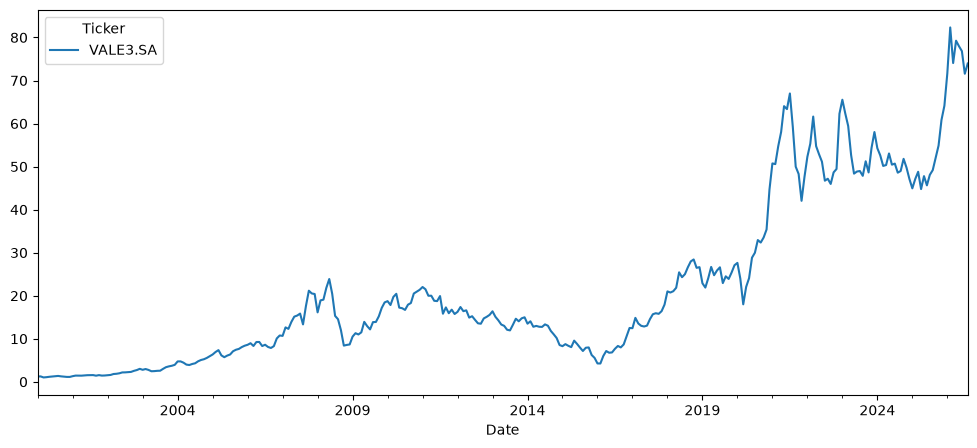

In [22]:
# Gráfico de fechamento na granularidade desejada
Minima['Low'].plot(figsize = (12,5))

<Axes: xlabel='Date'>

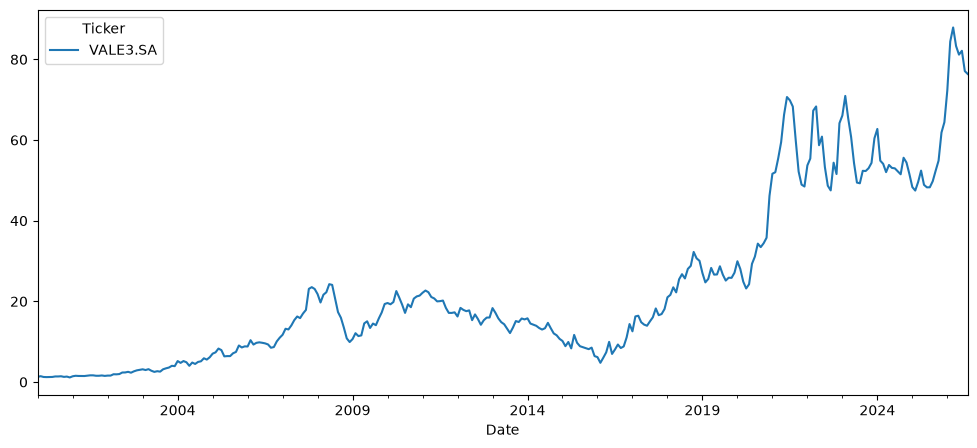

In [23]:
# Gráfico de fechamento na granularidade desejada
Abertura['Open'].plot(figsize = (12,5))

<Axes: xlabel='Date'>

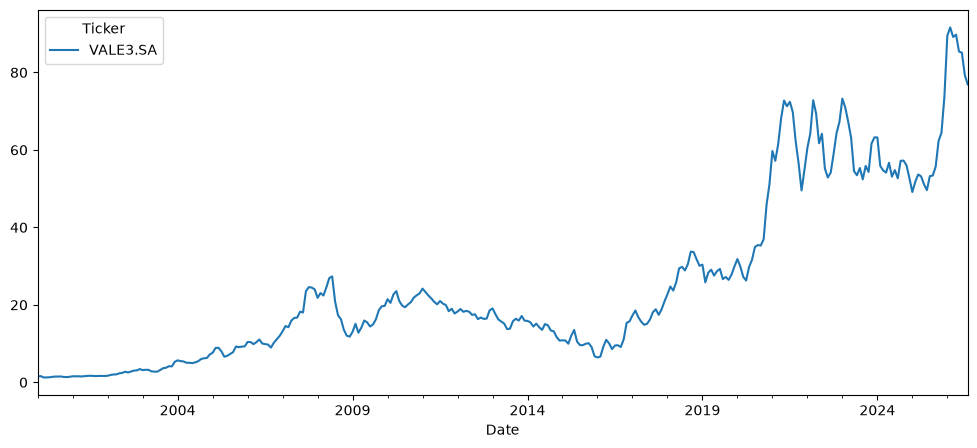

In [24]:
# Gráfico de fechamento na granularidade desejada
Maxima['High'].plot(figsize = (12,5))

<Axes: xlabel='Date'>

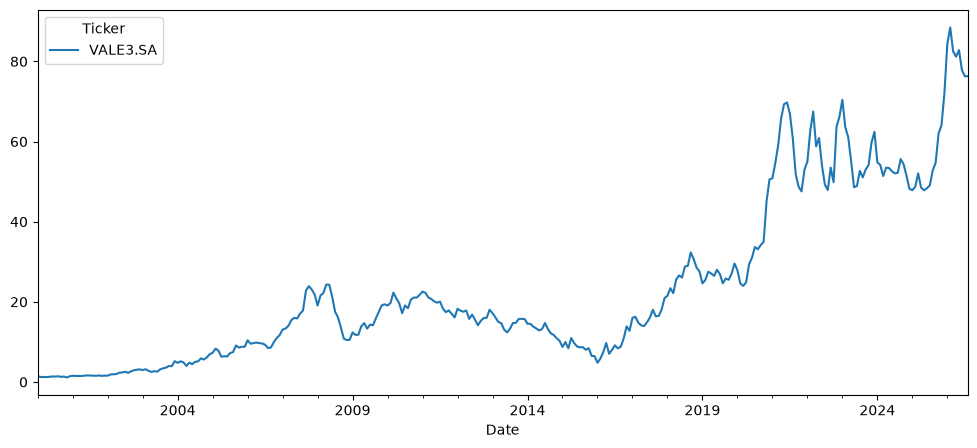

In [25]:
# Gráfico de fechamento na granularidade desejada
Fechamento['Close'].plot(figsize = (12,5))

In [26]:
# Gravação da série de cotações de fechamento em formato CSV
FechamentoDF = pd.DataFrame()
FechamentoDF.index = Fechamento['Close'].index
FechamentoDF.index.rename('Data', inplace = True)
FechamentoDF[AcaoB3] = Fechamento['Close']
FechamentoDF.to_csv('FechamentoAjustado' + AcaoB3 + '.csv')